<a href="https://colab.research.google.com/github/UchechukwuEric/Machine-Learning-Zoo-camp-Home-Work/blob/main/ZooCamp_MLHW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

2 Data Preparation

In [5]:
df =pd.read_csv("/car_fuel_efficiency_2026.csv")

In [6]:
df.head(5)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
df.columns= df.columns.str.lower().str.replace(' ', ' _')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


In [9]:
df[['origin','fuel_type','drivetrain']].apply(lambda x: x.str.lower().str.replace(' ', '_'))

,origin,fuel_type,drivetrain
0,europe,gasoline,front-wheel_drive
1,europe,diesel,front-wheel_drive
2,asia,gasoline,front-wheel_drive
3,europe,gasoline,front-wheel_drive
4,usa,diesel,front-wheel_drive
...,...,...,...
9995,usa,gasoline,all-wheel_drive
9996,asia,gasoline,all-wheel_drive
9997,usa,gasoline,all-wheel_drive
9998,usa,hybrid,rear-wheel_drive


Selecting Column for the task

In [10]:
selected_columns=['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']

In [11]:
df = df[selected_columns]

In [12]:
df.head(5)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


EDA

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Skewness: 0.08080419601878173


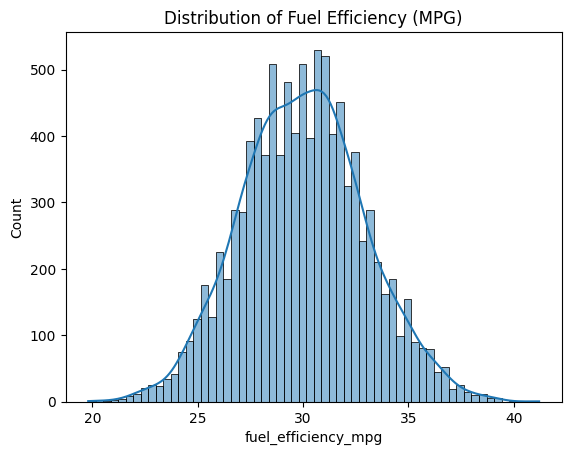

In [14]:
# Calculate the statistical skewness (values > 1 or < -1 indicate a long tail)
print("Skewness:", df['fuel_efficiency_mpg'].skew())

# Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['fuel_efficiency_mpg'], kde=True)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.show()

Checking for missing values

In [15]:
df.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


Summary Statistics

In [16]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


Prepare and split the dataset

In [17]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [18]:
n

10000

In [19]:
n_val,n_test,n_train

(2000, 2000, 6000)

In [20]:
df.iloc[[10, 0, 3, 5]]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
10,2410,NaN,4420,1978,26.8
0,2180,243.0,3870,2006,31.9
3,2130,258.0,4490,1989,28.5
5,2290,266.0,4260,2007,31.2


In [21]:
# Reset indices to avoid index mismatch issues
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Separate targets (y)
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

# Create feature DataFrames (X) by dropping the target variable
X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
X_test = df_test.drop(columns=['fuel_efficiency_mpg'])

### Next Step: Handling Missing Values
Now we can calculate the fill value (such as the mean or median of the `horsepower` column) using **only** the training set `X_train`, and use it to fill the missing values across all sets.

In [22]:
# Calculate the fill value using ONLY training data
horsepower_mean = X_train['horsepower'].mean()
print(f"Imputing missing horsepower values with training mean: {horsepower_mean:.2f}")

# Fill missing values in X_train, X_val, and X_test
X_train_filled = X_train.fillna(horsepower_mean)
X_val_filled = X_val.fillna(horsepower_mean)
X_test_filled = X_test.fillna(horsepower_mean)

# Check if any missing values remain
print("Missing values remaining in X_train_filled:", X_train_filled.isnull().sum().sum())

Imputing missing horsepower values with training mean: 254.46
Missing values remaining in X_train_filled: 0


In [23]:
def train_linear_regression(X, y):
    # Add a column of ones for the bias/intercept term
    ones = np.ones(X.shape[0])
    X_new = np.column_stack([ones, X])

    # Normal equation: w = (X_new^T * X_new)^(-1) * X_new^T * y
    XTX = X_new.T.dot(X_new)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X_new.T).dot(y)

    # Return bias (w_0) and weights (w_1 to w_n)
    return w[0], w[1:]

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

# --- Option 1: Imputing with the Mean (using already filled variables) ---
X_train_mean_filled = X_train_filled.values
X_val_mean_filled = X_val_filled.values

w_0_mean, w_mean = train_linear_regression(X_train_mean_filled, y_train)
y_pred_mean = w_0_mean + X_val_mean_filled.dot(w_mean)
rmse_mean = rmse(y_val, y_pred_mean)

# --- Option 2: Imputing with 0 ---
X_train_zero_filled = X_train.fillna(0).values
X_val_zero_filled = X_val.fillna(0).values

w_0_zero, w_zero = train_linear_regression(X_train_zero_filled, y_train)
y_pred_zero = w_0_zero + X_val_zero_filled.dot(w_zero)
rmse_zero = rmse(y_val, y_pred_zero)

# --- Output Results ---
print(f"RMSE with Mean Imputation: {round(rmse_mean, 3)}")
print(f"RMSE with Zero Imputation: {round(rmse_zero, 3)}")


RMSE with Mean Imputation: 2.202
RMSE with Zero Imputation: 2.205


In [26]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X_new = np.column_stack([ones, X])

    XTX = X_new.T.dot(X_new)
    # Add regularization to the diagonal, excluding the bias term (index 0)
    reg_matrix = r * np.eye(XTX.shape[0])
    reg_matrix[0, 0] = 0

    XTX_reg = XTX + reg_matrix
    XTX_inv = np.linalg.inv(XTX_reg)
    w = XTX_inv.dot(X_new.T).dot(y)

    return w[0], w[1:]

# Prepare the feature matrices filled with 0
X_train_zero = X_train.fillna(0).values
X_val_zero = X_val.fillna(0).values

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
results = {}

for r in r_values:
    w_0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)
    y_pred = w_0 + X_val_zero.dot(w)
    score = rmse(y_val, y_pred)
    results[r] = round(score, 4)
    print(f"r = {r:<5} | RMSE = {results[r]:.4f}")

best_r = min(results, key=results.get)
print(f"\nBest r: {best_r} (RMSE: {results[best_r]:.4f})")


r = 0     | RMSE = 2.2053
r = 0.01  | RMSE = 2.2053
r = 0.1   | RMSE = 2.2053
r = 1     | RMSE = 2.2053
r = 5     | RMSE = 2.2053
r = 10    | RMSE = 2.2053
r = 100   | RMSE = 2.2053

Best r: 0 (RMSE: 2.2053)


In [27]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for seed in seeds:
    # Shuffle index with the current seed
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # Split dataset
    df_train_temp = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val_temp = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    # Target variables
    y_train_temp = df_train_temp['fuel_efficiency_mpg'].values
    y_val_temp = df_val_temp['fuel_efficiency_mpg'].values

    # Features (and fill NAs with 0)
    X_train_temp = df_train_temp.drop(columns=['fuel_efficiency_mpg']).fillna(0).values
    X_val_temp = df_val_temp.drop(columns=['fuel_efficiency_mpg']).fillna(0).values

    # Train baseline linear regression
    w_0, w = train_linear_regression(X_train_temp, y_train_temp)

    # Validate and compute RMSE
    y_pred = w_0 + X_val_temp.dot(w)
    score = rmse(y_val_temp, y_pred)
    rmse_scores.append(score)
    print(f"Seed {seed} | RMSE: {score:.4f}")

# Calculate standard deviation
std_dev = np.std(rmse_scores)
print(f"\nStandard deviation of RMSE scores: {round(std_dev, 3)}")

Seed 0 | RMSE: 2.2392
Seed 1 | RMSE: 2.2021
Seed 2 | RMSE: 2.1634
Seed 3 | RMSE: 2.2044
Seed 4 | RMSE: 2.2019
Seed 5 | RMSE: 2.2458
Seed 6 | RMSE: 2.2697
Seed 7 | RMSE: 2.1908
Seed 8 | RMSE: 2.2166
Seed 9 | RMSE: 2.2070

Standard deviation of RMSE scores: 0.029


In [28]:
import numpy as np
import pandas as pd

# Split parameters
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Shuffle using seed 9
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

# Create splits
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# Combine train and validation datasets
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

# Separate features and targets
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

X_full_train = df_full_train.drop(columns=['fuel_efficiency_mpg'])
X_test = df_test.drop(columns=['fuel_efficiency_mpg'])

# Fill missing values with 0
X_full_train_zero = X_full_train.fillna(0).values
X_test_zero = X_test.fillna(0).values

# Train the model with r=0.001
w_0_final, w_final = train_linear_regression_reg(X_full_train_zero, y_full_train, r=0.001)

# Predict and calculate RMSE on test set
y_pred_test = w_0_final + X_test_zero.dot(w_final)
test_rmse = rmse(y_test, y_pred_test)

print(f"Test RMSE: {test_rmse:.3f}")


Test RMSE: 2.236


Dealing with missing value